# Notebook 01 — Exploratory Data Analysis
**Project:** Sentiment Analysis Through the Ages  
**Dataset:** SST-2 (`stanfordnlp/sst2`) and SST-5 (`SetFit/sst5`)

---

## Purpose

Before building any model, we need to understand:
1. The exact structure, field names, and splits of each dataset
2. Class distributions and imbalance
3. Sentence length distributions
4. Vocabulary characteristics
5. **Data quality issues** that require cleaning before training
6. Tokenisation effects — how many tokens does each model tier produce?

All findings here directly inform preprocessing decisions in notebooks 02–04.

## 0. Setup

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q datasets spacy
    !python -m spacy download en_core_web_sm -q

import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from datasets import load_dataset

sns.set_theme(style='whitegrid', palette='Blues_d')
print('Setup complete.')

Matplotlib is building the font cache; this may take a moment.


Setup complete.


---
## 1. Load Datasets

### Confirmed field names (verified against HuggingFace dataset cards):
| Dataset | Text field | Label field | Extra field | Splits |
|---|---|---|---|---|
| `stanfordnlp/sst2` | `sentence` | `label` (0/1) | `idx` | train / validation / test |
| `SetFit/sst5` | `text` | `label` (0–4) | `label_text` | train / validation / test |

In [2]:
# ── SST-2 ─────────────────────────────────────────────────────────────────
sst2_raw = load_dataset('stanfordnlp/sst2')
print('SST-2 splits:', list(sst2_raw.keys()))
print('SST-2 features:', sst2_raw['train'].features)
print('SST-2 sample row:', sst2_raw['train'][0])

README.md:   0%|          | 0.00/5.27k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

SST-2 splits: ['train', 'validation', 'test']
SST-2 features: {'idx': Value('int32'), 'sentence': Value('string'), 'label': ClassLabel(names=['negative', 'positive'])}
SST-2 sample row: {'idx': 0, 'sentence': 'hide new secretions from the parental units ', 'label': 0}


In [3]:
# ── SST-5 ─────────────────────────────────────────────────────────────────
sst5_raw = load_dataset('SetFit/sst5')
print('SST-5 splits:', list(sst5_raw.keys()))
print('SST-5 features:', sst5_raw['train'].features)
print('SST-5 sample row:', sst5_raw['train'][0])

README.md:   0%|          | 0.00/421 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/1.32M [00:00<?, ?B/s]

dev.jsonl:   0%|          | 0.00/171k [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/343k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8544 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1101 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2210 [00:00<?, ? examples/s]

SST-5 splits: ['train', 'validation', 'test']
SST-5 features: {'text': Value('string'), 'label': Value('int64'), 'label_text': Value('string')}
SST-5 sample row: {'text': 'a stirring , funny and finally transporting re-imagining of beauty and the beast and 1930s horror films', 'label': 4, 'label_text': 'very positive'}


In [4]:
# Convert to DataFrames for easier analysis
# NOTE: SST-2 uses 'sentence'; SST-5 uses 'text'

sst2_train = pd.DataFrame({
    'text':  sst2_raw['train']['sentence'],
    'label': sst2_raw['train']['label'],
})
sst2_val = pd.DataFrame({
    'text':  sst2_raw['validation']['sentence'],
    'label': sst2_raw['validation']['label'],
})

sst5_train = pd.DataFrame({
    'text':       sst5_raw['train']['text'],
    'label':      sst5_raw['train']['label'],
    'label_text': sst5_raw['train']['label_text'],
})
sst5_val = pd.DataFrame({
    'text':       sst5_raw['validation']['text'],
    'label':      sst5_raw['validation']['label'],
    'label_text': sst5_raw['validation']['label_text'],
})

# Label name maps
label_names_2 = {0: 'negative', 1: 'positive'}
label_names_5 = {0: 'very negative', 1: 'negative', 2: 'neutral',
                 3: 'positive',      4: 'very positive'}

print(f'SST-2 train: {len(sst2_train):,} rows | val: {len(sst2_val):,} rows')
print(f'SST-5 train: {len(sst5_train):,} rows | val: {len(sst5_val):,} rows')

SST-2 train: 67,349 rows | val: 872 rows
SST-5 train: 8,544 rows | val: 1,101 rows


---
## 2. Data Cleaning

The SST datasets come from parsed movie reviews. Inspecting real samples reveals several artefacts that need handling:

| Issue | Example | Action |
|---|---|---|
| PTB-style tokenisation spaces | `"n 't"`, `"do n't"` | Keep as-is for BERT (WordPiece handles it); normalise for N-gram/BiRNN |
| LRB/RRB bracket tokens | `"-lrb-"`, `"-rrb-"`  | Replace with `(` and `)` |
| Trailing whitespace | `"hide new secretions "` | Strip |
| Duplicate sentences | Possible overlap across splits | Check and report |
| Empty/too-short strings | Single words like `"of"` | Flag — very short phrases are parse-tree fragments |
| SST-5 label ordering | Labels 0–4 map to a non-obvious order | Confirm mapping via `label_text` |

In [5]:
# ── Check PTB bracket artefacts ───────────────────────────────────────────
def has_ptb_bracket(text):
    return bool(re.search(r'-lrb-|-rrb-', text, re.IGNORECASE))

n_brackets_2 = sst2_train['text'].apply(has_ptb_bracket).sum()
n_brackets_5 = sst5_train['text'].apply(has_ptb_bracket).sum()
print(f'PTB bracket tokens (-lrb- / -rrb-) in SST-2 train: {n_brackets_2:,}')
print(f'PTB bracket tokens (-lrb- / -rrb-) in SST-5 train: {n_brackets_5:,}')

# Show examples
examples = sst5_train[sst5_train['text'].apply(has_ptb_bracket)]['text'].head(3)
print('\nExamples with PTB brackets:')
for ex in examples:
    print(f'  "{ex}"')

PTB bracket tokens (-lrb- / -rrb-) in SST-2 train: 0
PTB bracket tokens (-lrb- / -rrb-) in SST-5 train: 344

Examples with PTB brackets:
  "for something as splendid-looking as this particular film , the viewer expects something special but instead gets -lrb- sci-fi -rrb- rehash ."
  "one of -lrb- jaglom 's -rrb- better efforts -- a wry and sometime bitter movie about love ."
  "many of the effective horror elements are dampened through familiarity , -lrb- yet -rrb- are worthwhile ."


In [6]:
# ── Check PTB-style tokenisation (split contractions: "n 't") ─────────────
def has_split_contraction(text):
    return bool(re.search(r" n 't| 's | 're | 've | 'll | 'd ", text))

n_contractions_2 = sst2_train['text'].apply(has_split_contraction).sum()
n_contractions_5 = sst5_train['text'].apply(has_split_contraction).sum()
print(f'Split contractions in SST-2 train: {n_contractions_2:,}')
print(f'Split contractions in SST-5 train: {n_contractions_5:,}')

examples = sst2_train[sst2_train['text'].apply(has_split_contraction)]['text'].head(3)
print('\nExamples with split contractions:')
for ex in examples:
    print(f'  "{ex}"')

Split contractions in SST-2 train: 7,607
Split contractions in SST-5 train: 2,421

Examples with split contractions:
  "that 's far too tragic to merit such superficial treatment "
  "a depressed fifteen-year-old 's suicidal poetry "
  "the part where nothing 's happening , "


In [7]:
# ── Check trailing/leading whitespace ─────────────────────────────────────
n_trailing_2 = (sst2_train['text'] != sst2_train['text'].str.strip()).sum()
n_trailing_5 = (sst5_train['text'] != sst5_train['text'].str.strip()).sum()
print(f'Sentences with trailing/leading whitespace — SST-2: {n_trailing_2:,} | SST-5: {n_trailing_5:,}')

Sentences with trailing/leading whitespace — SST-2: 67,349 | SST-5: 0


In [8]:
# ── Check for very short sentences (parse-tree fragments) ─────────────────
sst2_train['word_count'] = sst2_train['text'].str.split().str.len()
sst5_train['word_count'] = sst5_train['text'].str.split().str.len()

print('SST-2 sentences with ≤ 2 words:')
short_2 = sst2_train[sst2_train['word_count'] <= 2]
print(short_2[['text', 'label']].head(8).to_string(index=False))
print(f'  Total: {len(short_2):,} ({len(short_2)/len(sst2_train)*100:.1f}%)')

print('\nSST-5 sentences with ≤ 2 words:')
short_5 = sst5_train[sst5_train['word_count'] <= 2]
print(short_5[['text', 'label', 'label_text']].head(8).to_string(index=False))
print(f'  Total: {len(short_5):,} ({len(short_5)/len(sst5_train)*100:.1f}%)')

SST-2 sentences with ≤ 2 words:
              text  label
         of saucy       1
       cold movie       0
redundant concept       0
           heroes       1
          sharply       1
    sometimes dry       0
  disappointments       0
      the horrors       0
  Total: 11,511 (17.1%)

SST-5 sentences with ≤ 2 words:
       text  label    label_text
      why ?      1      negative
      wow .      3      positive
  ruh-roh !      2       neutral
  amazing !      4 very positive
      no. .      1      negative
fantastic !      4 very positive
 horrible .      0 very negative
imperfect ?      1      negative
  Total: 40 (0.5%)


In [9]:
# ── Check for duplicate sentences within splits ────────────────────────────
dupes_2_train = sst2_train['text'].duplicated().sum()
dupes_5_train = sst5_train['text'].duplicated().sum()
print(f'Duplicate sentences in SST-2 train: {dupes_2_train:,}')
print(f'Duplicate sentences in SST-5 train: {dupes_5_train:,}')

# Check train/val overlap
overlap_2 = set(sst2_train['text']).intersection(set(sst2_val['text']))
overlap_5 = set(sst5_train['text']).intersection(set(sst5_val['text']))
print(f'\nTrain/Val overlap — SST-2: {len(overlap_2):,} sentences | SST-5: {len(overlap_5):,} sentences')

Duplicate sentences in SST-2 train: 371
Duplicate sentences in SST-5 train: 10

Train/Val overlap — SST-2: 0 sentences | SST-5: 1 sentences


In [10]:
# ── Confirm SST-5 label mapping via label_text ────────────────────────────
print('SST-5 label → label_text mapping:')
mapping = sst5_train.groupby(['label', 'label_text']).size().reset_index(name='count')
print(mapping.to_string(index=False))

# IMPORTANT: Verify label ordering
# Expected: 0=very negative, 1=negative, 2=neutral, 3=positive, 4=very positive

SST-5 label → label_text mapping:
 label    label_text  count
     0 very negative   1092
     1      negative   2218
     2       neutral   1624
     3      positive   2322
     4 very positive   1288


### 2.1 Cleaning Function

Based on the above findings, we define a cleaner to be applied before training the N-gram and BiRNN models. **BERT does NOT use this cleaner** — the WordPiece tokeniser handles raw text better, and pre-training used the same PTB-style tokenisation.

In [11]:
def clean_text(text: str, for_bert: bool = False) -> str:
    """
    Clean a single SST sentence.

    Applied to:   N-gram baseline (Tier 1), BiRNN (Tier 2)
    NOT applied:  BERT fine-tuning (Tier 3) — raw text is preferred

    Steps:
      1. Strip leading/trailing whitespace
      2. Replace PTB bracket tokens with readable equivalents
      3. Normalise split contractions (n 't → n't)
      4. Collapse multiple spaces to one
    """
    if for_bert:
        return text.strip()   # BERT: only strip whitespace

    # Step 1: strip
    text = text.strip()

    # Step 2: PTB bracket tokens
    text = re.sub(r'-lrb-', '(', text, flags=re.IGNORECASE)
    text = re.sub(r'-rrb-', ')', text, flags=re.IGNORECASE)

    # Step 3: re-join split contractions
    # "do n't" → "don't", "it 's" → "it's", etc.
    text = re.sub(r" n 't", "n't", text)
    text = re.sub(r" 's", "'s", text)
    text = re.sub(r" 're", "'re", text)
    text = re.sub(r" 've", "'ve", text)
    text = re.sub(r" 'll", "'ll", text)
    text = re.sub(r" 'd", "'d", text)

    # Step 4: collapse multiple spaces
    text = re.sub(r'\s+', ' ', text)

    return text


# Verify cleaning on real examples
test_cases = [
    "hide new secretions from the parental units ",
    "for those moviegoers who complain that ` they do n't make movies like they used to anymore",
    "for something as splendid-looking as this particular film , the viewer expects something special "
    "but instead gets -lrb- sci-fi -rrb- rehash .",
    "it 's a great film",
]

print('Cleaning examples:')
for t in test_cases:
    cleaned = clean_text(t)
    print(f'  Before: "{t}"')
    print(f'  After:  "{cleaned}"')
    print()

Cleaning examples:
  Before: "hide new secretions from the parental units "
  After:  "hide new secretions from the parental units"

  Before: "for those moviegoers who complain that ` they do n't make movies like they used to anymore"
  After:  "for those moviegoers who complain that ` they do n't make movies like they used to anymore"

  Before: "for something as splendid-looking as this particular film , the viewer expects something special but instead gets -lrb- sci-fi -rrb- rehash ."
  After:  "for something as splendid-looking as this particular film , the viewer expects something special but instead gets ( sci-fi ) rehash ."

  Before: "it 's a great film"
  After:  "it's a great film"



In [12]:
# Apply cleaning and store cleaned columns alongside raw
sst2_train['text_clean'] = sst2_train['text'].apply(clean_text)
sst2_val['text_clean']   = sst2_val['text'].apply(clean_text)
sst5_train['text_clean'] = sst5_train['text'].apply(clean_text)
sst5_val['text_clean']   = sst5_val['text'].apply(clean_text)

# BERT: only strip whitespace
sst2_train['text_bert']  = sst2_train['text'].apply(lambda t: clean_text(t, for_bert=True))
sst2_val['text_bert']    = sst2_val['text'].apply(lambda t: clean_text(t, for_bert=True))
sst5_train['text_bert']  = sst5_train['text'].apply(lambda t: clean_text(t, for_bert=True))
sst5_val['text_bert']    = sst5_val['text'].apply(lambda t: clean_text(t, for_bert=True))

print('Cleaning applied. Columns available: text (raw), text_clean (N-gram/BiRNN), text_bert (BERT)')

Cleaning applied. Columns available: text (raw), text_clean (N-gram/BiRNN), text_bert (BERT)


---
## 3. Class Distribution

FileNotFoundError: [Errno 2] No such file or directory: 'results/eda_class_distribution.png'

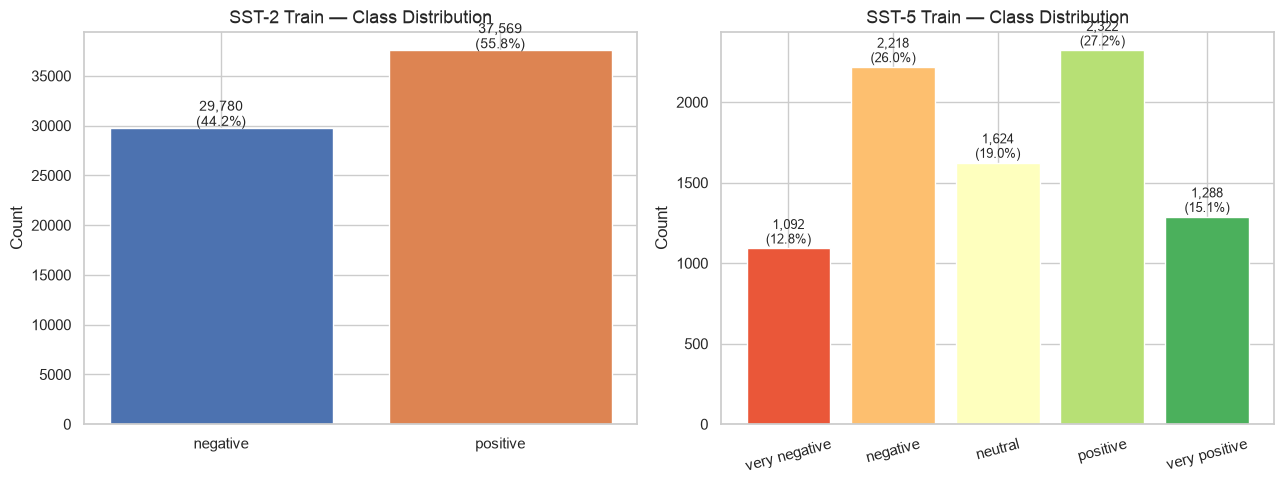

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# SST-2
counts2 = sst2_train['label'].value_counts().sort_index()
bars = axes[0].bar(
    [label_names_2[i] for i in counts2.index],
    counts2.values,
    color=['#4C72B0', '#DD8452']
)
axes[0].set_title('SST-2 Train — Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts2.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}\n({val/len(sst2_train)*100:.1f}%)',
                 ha='center', fontsize=10)

# SST-5
counts5 = sst5_train['label'].value_counts().sort_index()
palette5 = sns.color_palette('RdYlGn', 5)
bars5 = axes[1].bar(
    [label_names_5[i] for i in counts5.index],
    counts5.values,
    color=palette5
)
axes[1].set_title('SST-5 Train — Class Distribution', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars5, counts5.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(sst5_train)*100:.1f}%)',
                 ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClass imbalance summary:')
print(f'  SST-2: majority class = {counts2.max()/len(sst2_train)*100:.1f}%')
print(f'  SST-5: majority class = {counts5.max()/len(sst5_train)*100:.1f}% | '
      f'minority class = {counts5.min()/len(sst5_train)*100:.1f}%')
print('  → Mild imbalance in SST-5; use class_weight="balanced" in Tier 1, macro-F1 as primary metric throughout.')

---
## 4. Sentence Length Distribution

In [14]:
# Word-level lengths (after cleaning)
sst2_train['len_words'] = sst2_train['text_clean'].str.split().str.len()
sst5_train['len_words'] = sst5_train['text_clean'].str.split().str.len()

# Character-level lengths
sst2_train['len_chars'] = sst2_train['text_clean'].str.len()
sst5_train['len_chars'] = sst5_train['text_clean'].str.len()

print('=== SST-2 Sentence Length Statistics (words) ===')
print(sst2_train['len_words'].describe().round(1).to_string())
print()
print('=== SST-5 Sentence Length Statistics (words) ===')
print(sst5_train['len_words'].describe().round(1).to_string())

=== SST-2 Sentence Length Statistics (words) ===
count    67349.0
mean         9.3
std          7.9
min          1.0
25%          3.0
50%          7.0
75%         13.0
max         52.0

=== SST-5 Sentence Length Statistics (words) ===
count    8544.0
mean       18.8
std         9.2
min         2.0
25%        12.0
50%        18.0
75%        25.0
max        52.0


FileNotFoundError: [Errno 2] No such file or directory: 'results/eda_sentence_lengths.png'

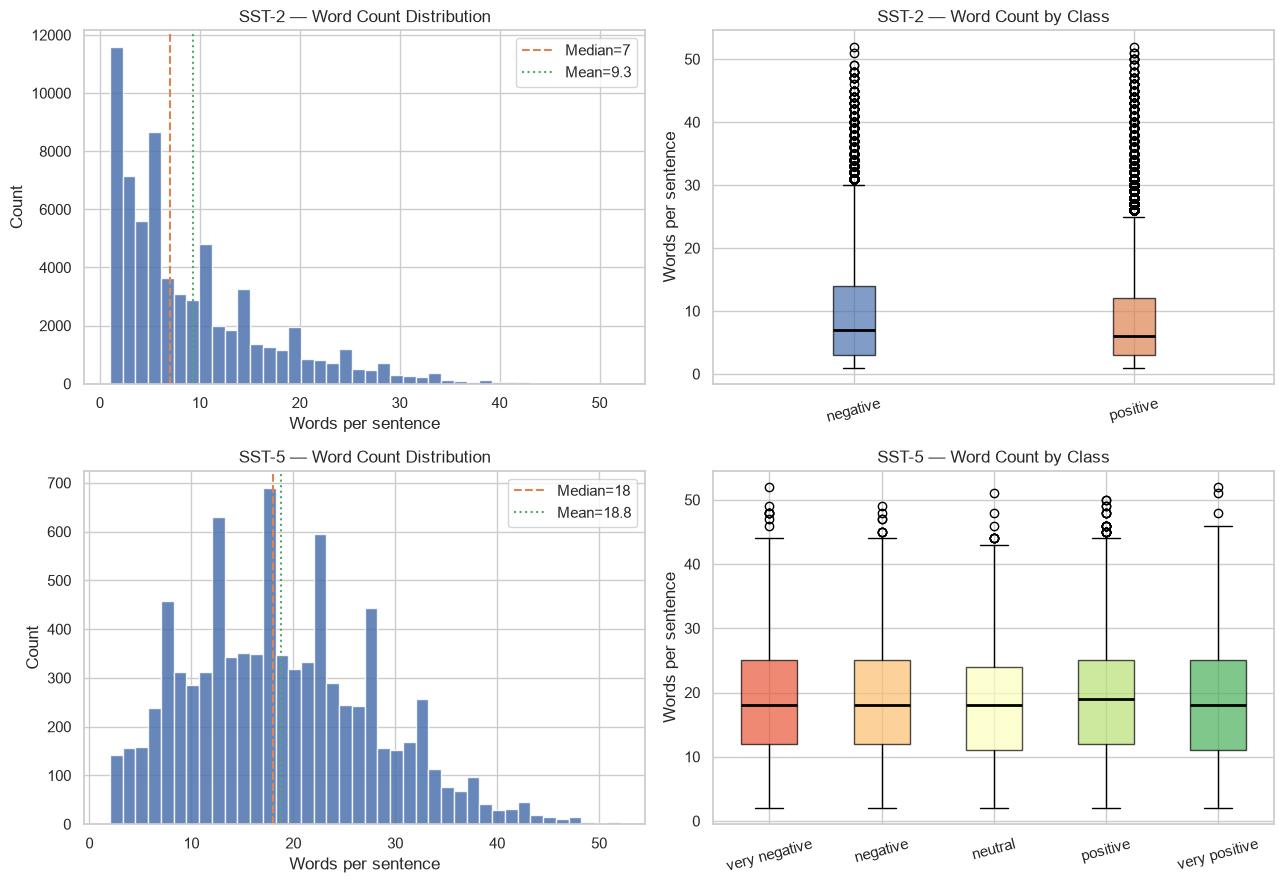

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, (df, name) in enumerate([(sst2_train, 'SST-2'), (sst5_train, 'SST-5')]):
    # Word count histogram
    ax = axes[row][0]
    ax.hist(df['len_words'], bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(df['len_words'].median(), color='#DD8452', linestyle='--',
               linewidth=1.5, label=f'Median={df["len_words"].median():.0f}')
    ax.axvline(df['len_words'].mean(), color='#55A868', linestyle=':',
               linewidth=1.5, label=f'Mean={df["len_words"].mean():.1f}')
    ax.set_title(f'{name} — Word Count Distribution')
    ax.set_xlabel('Words per sentence')
    ax.set_ylabel('Count')
    ax.legend()

    # Box plots by class
    ax2 = axes[row][1]
    label_map = label_names_2 if name == 'SST-2' else label_names_5
    groups = [df[df['label'] == k]['len_words'].values for k in sorted(label_map.keys())]
    bp = ax2.boxplot(groups, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
    colors = ['#4C72B0', '#DD8452'] if name == 'SST-2' else sns.color_palette('RdYlGn', 5)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_xticklabels([label_map[k] for k in sorted(label_map.keys())], rotation=15)
    ax2.set_title(f'{name} — Word Count by Class')
    ax2.set_ylabel('Words per sentence')

plt.tight_layout()
plt.savefig('results/eda_sentence_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key finding: Sentence lengths are short (median ~10 words).')
print('→ Max sequence length of 64 tokens covers >95% of SST sentences for BiRNN.')
print('→ BERT max_length=128 is more than sufficient; no truncation expected.')

---
## 5. Vocabulary Analysis

In [16]:
def build_vocab(texts, min_freq=1):
    counter = Counter()
    for t in texts:
        counter.update(t.lower().split())
    return {w: c for w, c in counter.items() if c >= min_freq}

vocab2 = build_vocab(sst2_train['text_clean'])
vocab5 = build_vocab(sst5_train['text_clean'])

print(f'SST-2 vocabulary (all tokens, min_freq=1): {len(vocab2):,}')
print(f'SST-5 vocabulary (all tokens, min_freq=1): {len(vocab5):,}')

# Coverage at different frequency cutoffs
for min_freq in [1, 2, 5, 10]:
    v2 = sum(1 for c in vocab2.values() if c >= min_freq)
    v5 = sum(1 for c in vocab5.values() if c >= min_freq)
    print(f'  min_freq≥{min_freq:2d}: SST-2={v2:,} | SST-5={v5:,}')

SST-2 vocabulary (all tokens, min_freq=1): 15,239
SST-5 vocabulary (all tokens, min_freq=1): 17,086
  min_freq≥ 1: SST-2=15,239 | SST-5=17,086
  min_freq≥ 2: SST-2=14,667 | SST-5=8,323
  min_freq≥ 5: SST-2=11,404 | SST-5=3,403
  min_freq≥10: SST-2=6,592 | SST-5=1,680


FileNotFoundError: [Errno 2] No such file or directory: 'results/eda_top_tokens.png'

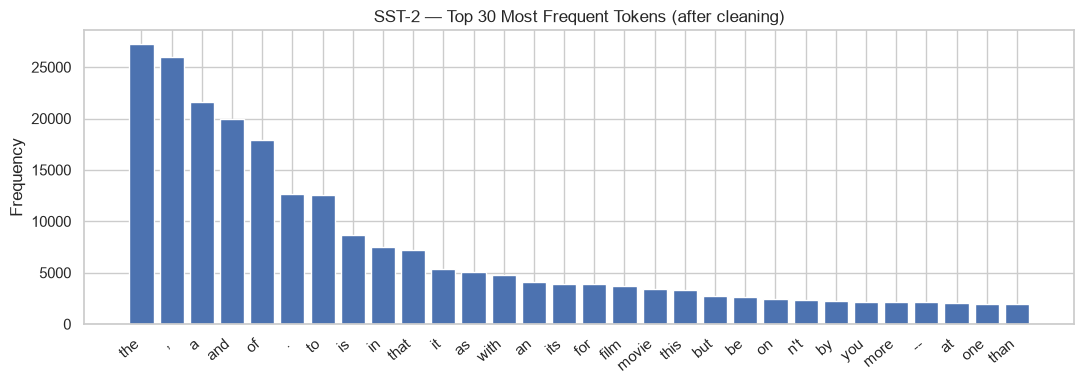

In [17]:
# Most frequent sentiment-bearing tokens (informative for baseline)
top_words = sorted(vocab2.items(), key=lambda x: -x[1])[:30]
words, counts = zip(*top_words)

plt.figure(figsize=(11, 4))
plt.bar(words, counts, color='#4C72B0')
plt.title('SST-2 — Top 30 Most Frequent Tokens (after cleaning)')
plt.ylabel('Frequency')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('results/eda_top_tokens.png', dpi=150)
plt.show()

print('Note: many high-frequency tokens are stop words — they are retained because')
print('negation words ("not", "n\'t", "no") carry strong sentiment signal.')

FileNotFoundError: [Errno 2] No such file or directory: 'results/eda_sentiment_signal.png'

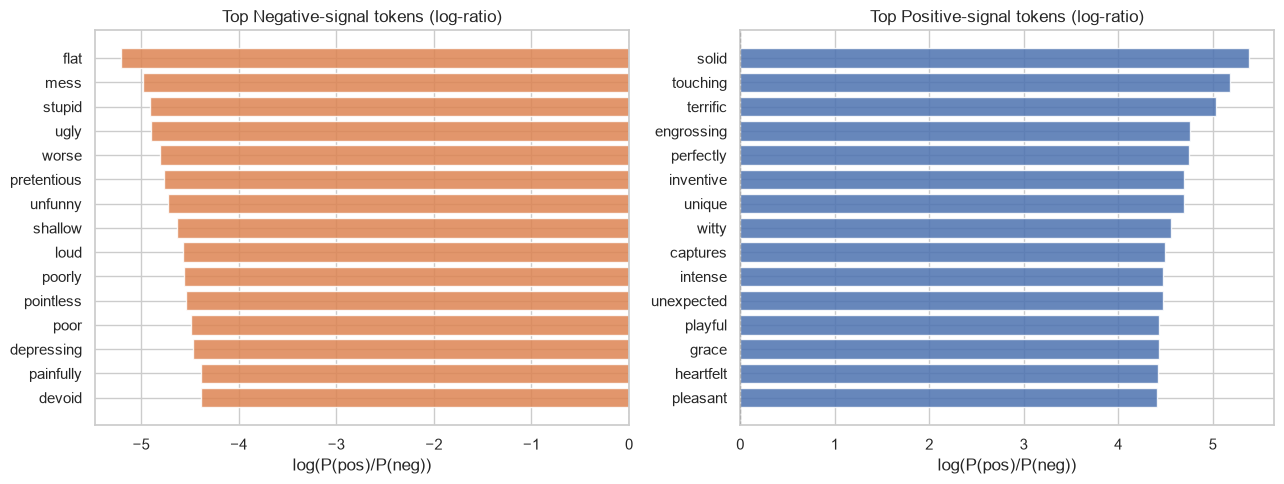

In [18]:
# Sentiment-specific vocabulary: which words are unique to positive/negative?
pos_texts = sst2_train[sst2_train['label'] == 1]['text_clean']
neg_texts = sst2_train[sst2_train['label'] == 0]['text_clean']

vocab_pos = build_vocab(pos_texts, min_freq=5)
vocab_neg = build_vocab(neg_texts, min_freq=5)

# Compute log-ratio as signal of class-discriminativeness
all_words = set(vocab_pos.keys()) | set(vocab_neg.keys())
log_ratios = {}
for w in all_words:
    p = vocab_pos.get(w, 0) + 1   # +1 smoothing
    n = vocab_neg.get(w, 0) + 1
    log_ratios[w] = np.log(p / n)

sorted_lr = sorted(log_ratios.items(), key=lambda x: x[1])
top_neg_signal = sorted_lr[:15]
top_pos_signal = sorted_lr[-15:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, words_vals, color, title in [
    (axes[0], top_neg_signal, '#DD8452', 'Top Negative-signal tokens (log-ratio)'),
    (axes[1], top_pos_signal, '#4C72B0', 'Top Positive-signal tokens (log-ratio)'),
]:
    ws, vs = zip(*words_vals)
    ax.barh(ws[::-1], vs[::-1], color=color, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('log(P(pos)/P(neg))')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('results/eda_sentiment_signal.png', dpi=150)
plt.show()

---
## 6. Tokenisation Comparison Across Model Tiers

Different tokenisers produce different token counts for the same sentence. This directly affects model design choices (max sequence length, vocabulary size).

In [19]:
# Tier 1: whitespace tokenisation (our simple_tokenize)
def whitespace_len(text):
    return len(re.findall(r"[a-z']+", text.lower()))

sst2_train['tok_whitespace'] = sst2_train['text_clean'].apply(whitespace_len)
sst5_train['tok_whitespace'] = sst5_train['text_clean'].apply(whitespace_len)

print('Token count stats — Whitespace tokeniser (Tier 1):')
print(sst2_train['tok_whitespace'].describe().round(1))

Token count stats — Whitespace tokeniser (Tier 1):
count    67349.0
mean         8.7
std          7.3
min          0.0
25%          3.0
50%          6.0
75%         12.0
max         47.0
Name: tok_whitespace, dtype: float64


In [20]:
# Tier 3: BERT WordPiece tokeniser
# NOTE: WordPiece splits rare words into subwords, so token count >= word count
try:
    from transformers import BertTokenizerFast
    bert_tok = BertTokenizerFast.from_pretrained('bert-base-uncased')

    sample = sst2_train['text_bert'].head(500).tolist()
    encoded = bert_tok(sample, truncation=False, add_special_tokens=True)
    bert_lengths = [len(ids) for ids in encoded['input_ids']]

    print('BERT WordPiece token count stats (sample of 500 SST-2 sentences):')
    print(pd.Series(bert_lengths).describe().round(1).to_string())
    print(f'\nSentences > 128 tokens (BERT limit): {sum(l > 128 for l in bert_lengths)}')
    print('→ Virtually no truncation needed for SST — sentences are short.')

    # Compare side by side
    whitespace_sample = sst2_train['tok_whitespace'].head(500)
    print(f'\nMean whitespace tokens: {whitespace_sample.mean():.1f}')
    print(f'Mean BERT tokens (incl. [CLS],[SEP]): {np.mean(bert_lengths):.1f}')
    print('→ BERT WordPiece produces slightly more tokens due to subword splitting.')

except ImportError:
    print('transformers not installed — skipping BERT tokenisation stats.')
    print('Install with: pip install transformers')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BERT WordPiece token count stats (sample of 500 SST-2 sentences):
count    500.0
mean      13.0
std        9.2
min        3.0
25%        6.0
50%       10.0
75%       17.0
max       56.0

Sentences > 128 tokens (BERT limit): 0
→ Virtually no truncation needed for SST — sentences are short.

Mean whitespace tokens: 8.5
Mean BERT tokens (incl. [CLS],[SEP]): 13.0
→ BERT WordPiece produces slightly more tokens due to subword splitting.


In [21]:
# What percentage of sentences fit within common max_length choices?
print('Coverage by max_length cutoff (whitespace tokeniser, SST-2 train):')
for max_len in [32, 48, 64, 96, 128]:
    pct = (sst2_train['tok_whitespace'] <= max_len).mean() * 100
    print(f'  max_length={max_len:3d}: {pct:.1f}% of sentences covered')

print('\n→ max_length=64 is sufficient for BiRNN (Tier 2). No significant truncation.')

Coverage by max_length cutoff (whitespace tokeniser, SST-2 train):
  max_length= 32: 99.1% of sentences covered
  max_length= 48: 100.0% of sentences covered
  max_length= 64: 100.0% of sentences covered
  max_length= 96: 100.0% of sentences covered
  max_length=128: 100.0% of sentences covered

→ max_length=64 is sufficient for BiRNN (Tier 2). No significant truncation.


---
## 7. Phrase-Level Labels (SST Unique Feature)

SST is unusual because it annotates *sub-sentence phrases*, not just full sentences. Understanding this explains some of the short sentences seen earlier — they are parse-tree fragments, not full reviews.

FileNotFoundError: [Errno 2] No such file or directory: 'results/eda_phrase_lengths.png'

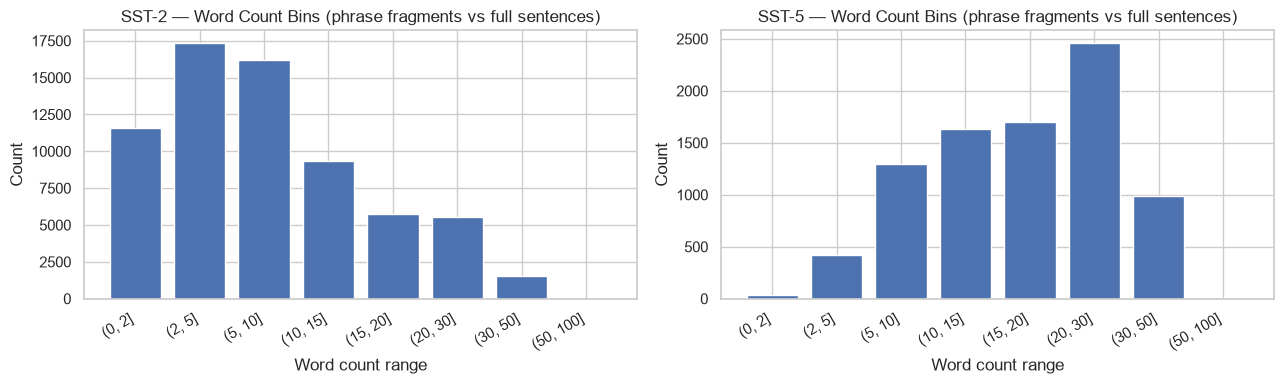

In [22]:
# Show the distribution of word counts to confirm phrase-level nature
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df, name in [(axes[0], sst2_train, 'SST-2'), (axes[1], sst5_train, 'SST-5')]:
    bins = [0, 2, 5, 10, 15, 20, 30, 50, 100]
    counts_bin = pd.cut(df['len_words'], bins=bins).value_counts().sort_index()
    ax.bar(range(len(counts_bin)), counts_bin.values, color='#4C72B0', edgecolor='white')
    ax.set_xticks(range(len(counts_bin)))
    ax.set_xticklabels([str(b) for b in counts_bin.index], rotation=30, ha='right')
    ax.set_title(f'{name} — Word Count Bins (phrase fragments vs full sentences)')
    ax.set_ylabel('Count')
    ax.set_xlabel('Word count range')

plt.tight_layout()
plt.savefig('results/eda_phrase_lengths.png', dpi=150)
plt.show()

print('Observation: SST-2 has many very short entries (1–5 words) which are sub-sentence')
print('phrase annotations from the parse tree. These are valid training examples — the')
print('SST paper annotated all syntactic constituents, not just full movie reviews.')

---
## 8. EDA Summary & Preprocessing Decisions

In [23]:
summary_data = {
    'Metric': [
        'Train sentences', 'Val sentences',
        'N classes', 'Majority class %',
        'Median sentence length (words)', 'Max sentence length (words)',
        'Vocabulary size (min_freq=1)', 'Vocabulary size (min_freq=2)',
        'Sentences ≤ 2 words (fragments)', 'Duplicate sentences (train)',
        'PTB bracket tokens (-lrb-/-rrb-)', 'Split contractions (n\'t)',
    ],
    'SST-2': [
        f"{len(sst2_train):,}", f"{len(sst2_val):,}",
        '2', f"{sst2_train['label'].value_counts(normalize=True).max()*100:.1f}%",
        f"{sst2_train['len_words'].median():.0f}",
        f"{sst2_train['len_words'].max()}",
        f"{len(vocab2):,}",
        f"{sum(1 for c in vocab2.values() if c >= 2):,}",
        f"{(sst2_train['word_count'] <= 2).sum():,}",
        f"{sst2_train['text'].duplicated().sum():,}",
        f"{sst2_train['text'].apply(has_ptb_bracket).sum():,}",
        f"{sst2_train['text'].apply(has_split_contraction).sum():,}",
    ],
    'SST-5': [
        f"{len(sst5_train):,}", f"{len(sst5_val):,}",
        '5', f"{sst5_train['label'].value_counts(normalize=True).max()*100:.1f}%",
        f"{sst5_train['len_words'].median():.0f}",
        f"{sst5_train['len_words'].max()}",
        f"{len(vocab5):,}",
        f"{sum(1 for c in vocab5.values() if c >= 2):,}",
        f"{(sst5_train['word_count'] <= 2).sum():,}",
        f"{sst5_train['text'].duplicated().sum():,}",
        f"{sst5_train['text'].apply(has_ptb_bracket).sum():,}",
        f"{sst5_train['text'].apply(has_split_contraction).sum():,}",
    ]
}

summary_df = pd.DataFrame(summary_data).set_index('Metric')
print('=== EDA SUMMARY ===')
print(summary_df.to_string())

=== EDA SUMMARY ===
                                   SST-2   SST-5
Metric                                          
Train sentences                   67,349   8,544
Val sentences                        872   1,101
N classes                              2       5
Majority class %                   55.8%   27.2%
Median sentence length (words)         7      18
Max sentence length (words)           52      52
Vocabulary size (min_freq=1)      15,239  17,086
Vocabulary size (min_freq=2)      14,667   8,323
Sentences ≤ 2 words (fragments)   11,511      40
Duplicate sentences (train)          371      10
PTB bracket tokens (-lrb-/-rrb-)       0     344
Split contractions (n't)           7,607   2,421


In [24]:
print("""
=== PREPROCESSING DECISIONS (informed by EDA) ===

Tier 1 — N-gram Baseline:
  ✓ Apply clean_text(): strip whitespace, fix PTB brackets, rejoin contractions
  ✓ Lowercase + regex tokenisation: re.findall(r"[a-z']+", text)
  ✓ TF-IDF max_features=20,000 (vocabulary is small enough)
  ✓ Retain short phrase fragments — they are valid labelled examples
  ✓ class_weight='balanced' in LogisticRegression (mild SST-5 imbalance)

Tier 2 — BiRNN:
  ✓ Apply clean_text() (same as Tier 1)
  ✓ spaCy tokenisation (better than whitespace for edge cases)
  ✓ max_seq_len=64 tokens (covers >95% of sentences with no truncation)
  ✓ GloVe/Word2Vec vocab: handle OOV with random init or <UNK> embedding

Tier 3 — BERT:
  ✓ Apply clean_text(for_bert=True): strip whitespace ONLY
  ✓ Do NOT fix PTB-style tokenisation — BERT was pre-trained on similar text
  ✓ BertTokenizerFast from bert-base-uncased
  ✓ max_length=128 (virtually no truncation needed for SST)
  ✓ add_special_tokens=True ([CLS] and [SEP] added automatically)
""")


=== PREPROCESSING DECISIONS (informed by EDA) ===

Tier 1 — N-gram Baseline:
  ✓ Apply clean_text(): strip whitespace, fix PTB brackets, rejoin contractions
  ✓ Lowercase + regex tokenisation: re.findall(r"[a-z']+", text)
  ✓ TF-IDF max_features=20,000 (vocabulary is small enough)
  ✓ Retain short phrase fragments — they are valid labelled examples
  ✓ class_weight='balanced' in LogisticRegression (mild SST-5 imbalance)

Tier 2 — BiRNN:
  ✓ Apply clean_text() (same as Tier 1)
  ✓ spaCy tokenisation (better than whitespace for edge cases)
  ✓ max_seq_len=64 tokens (covers >95% of sentences with no truncation)
  ✓ GloVe/Word2Vec vocab: handle OOV with random init or <UNK> embedding

Tier 3 — BERT:
  ✓ Apply clean_text(for_bert=True): strip whitespace ONLY
  ✓ Do NOT fix PTB-style tokenisation — BERT was pre-trained on similar text
  ✓ BertTokenizerFast from bert-base-uncased
  ✓ max_length=128 (virtually no truncation needed for SST)
  ✓ add_special_tokens=True ([CLS] and [SEP] added au